In [99]:
from utils import * 
import subprocess
import json 
from scipy.spatial.distance import pdist, cdist
# from scipy.spatial.distance import pdist, squareform
import toytree
from hole import * 
import glob


%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
FIGURE_DIR = os.path.abspath('./figures/analysis-1-cluster_3')
os.makedirs(FIGURE_DIR, exist_ok=True)


In [3]:
get_num_subunits = lambda name : int(re.search(r'(\d+)mer', name).group(1))

In [98]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id != 'bz_12')].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_3.faa')
# subprocess.run('muscle -align ../data/genes/cluster_3.faa -output ../data/genes/cluster_3.afa', shell=True, check=True)
msa = MSAFile.from_file('../data/genes/cluster_3.afa')
dssp_msa = map_dssp_to_msa(msa, dssp_output_dir='../data/genes/dssp')

for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_3 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_3 gene length:', genes_df.seq.apply(len).max())

GENOME_ID_TO_GENE_ID_MAP = genes_df.reset_index(names='gene_id').set_index('genome_id').gene_id.to_dict()
SEQ_TO_CLUSTER_ID_MAP = genes_df.set_index('seq').cluster_id.to_dict()

orfm.bz_0.1_191
orfm.bz_1.1_155
orfm.bz_2.1_22
orfm.bz_3.1_43
orfm.bz_4.1_184
orfm.bz_5.1_151
orfm.bz_7.1_194
orfm.bz_8.1_215
orfm.bz_9.1_34
orfm.bz_10.1_15
orfm.bz_11.1_23

Minimum cluster_3 gene length: 244
Maximum cluster_3 gene length: 266


In [5]:
ATPASE_DOMAIN_COORDS = (24, 215) # Relative to the Betazoid cluster_3 MSA. This is 
msa = MSAFile.from_file(path='../data/genes/cluster_3.afa')

# Use the MSA to determine the ATPase domain coordinates for each sequence, even those lacking an annotation. 
for gene_id in genes_df.index:
    genes_df.loc[gene_id, 'atpase_domain_start'] = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'atpase_domain_stop'] = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[1], gene_id)

In [6]:
# (1) Downloaded all bacterial (reviewed), archaeal (reviewed), and viral (all) sequences annotated as SSF52540 (P-loop ATPase) from UniProt. 
# (2) Constructed a BLAST database with the downloaded sequences to find those which are the best match. 
#   makeblastdb -in uniprot_supfam_SSF52540.faa -out ./blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540 -dbtype prot
# (3) BLAST-aligned the cluster_3 sequences against the database. 
#   blastp -db ../data/genes/blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540 -out ../data/genes/blast/cluster_3-blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540.tsv -query ../data/genes/cluster_3.faa -outfmt "6 qseqid sseqid pident length evalue bitscore qstart qend sstart send" -max_hsps 1 -max_target_seqs 5000
# (4) Clustered the sequences at 80% identity using mmseqs. 
#   mmseqs easy-cluster uniprot_supfam_SSF52540_reviewed.faa ./mmseqs/uniprot_supfam_SSF52540_reviewed tmp --min-seq-id 0.9
# (5) Run InterProScan on the cluster representatives and extract the ATPase domains. 

MIN_PERCENT_IDENTITY = 20
MIN_ALIGNMENT_LENGTH = 100

BLASTP_DATABASE_PATH = '../data/genes/blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540'
BLASTP_QUERY_PATH = '../data/genes/cluster_3.faa'
BLASTP_OUTPUT_PATH = '../data/genes/blast/cluster_3-uniprot_supfam_SSF52540.tsv'
BLASTP_FIELDS = 'qseqid sseqid pident length evalue bitscore qstart qend sstart send sseq'

cmd = f'blastp -db {BLASTP_DATABASE_PATH} -out {BLASTP_OUTPUT_PATH} -query {BLASTP_QUERY_PATH} -outfmt "6 {BLASTP_FIELDS}" -max_hsps 1 -max_target_seqs 5000'
# subprocess.run(cmd, shell=True, check=True)

blast_df = pd.read_csv(BLASTP_OUTPUT_PATH, names=BLASTP_FIELDS.split(), sep='\t')
ref_atpase_gene_ids = blast_df[(blast_df.pident > MIN_PERCENT_IDENTITY) & (blast_df.length > MIN_ALIGNMENT_LENGTH)].sseqid.values.unique()
print('Number of UniProt ATPases with reasonable BLAST hits:', len(ref_atpase_gene_ids))

# Load the actual amino acid sequences from the UniProt FASTA file. 
if not os.path.exists('../data/genes/ref_atpase.faa'):
    ref_atpase_df = FASTAFile.from_file('../data/genes/uniprot_supfam_SSF52540.faa', ids=ref_atpase_gene_ids).to_df()
    FASTAFile.from_df(ref_atpase_df).write('../data/genes/ref_atpase.faa')
else:
    ref_atpase_df = FASTAFile.from_file('../data/genes/ref_atpase.faa').to_df()

ref_atpase_annot_df = pd.read_csv('../data/genes/ref_atpase.tsv', sep='\t', names=INTERPROSCAN_FIELDS)
ref_atpase_annot_df = ref_atpase_annot_df[ref_atpase_annot_df.accession == 'SSF52540'].drop_duplicates('gene_id')

ref_atpase_df['atpase_domain_start'] = ref_atpase_df.index.map(ref_atpase_annot_df.set_index('gene_id').start)
ref_atpase_df['atpase_domain_stop'] = ref_atpase_df.index.map(ref_atpase_annot_df.set_index('gene_id').stop)
ref_atpase_df = ref_atpase_df[~ref_atpase_df.atpase_domain_start.isnull()].copy()
ref_atpase_df = ref_atpase_df.drop_duplicates('seq')
print('Number of ATPase representatives with an annotated domain:', len(ref_atpase_df))

# Combine the reference ATPases with the Betazoid ATPases and grab the ATPase domain portion of each complete sequence. 
tree_df = pd.concat([genes_df[['seq', 'atpase_domain_start', 'atpase_domain_stop']], ref_atpase_df[['seq', 'atpase_domain_start', 'atpase_domain_stop']]])
tree_df['seq'] = tree_df.apply(lambda row : row.seq[int(row.atpase_domain_start):int(row.atpase_domain_stop)], axis=1)

# FASTAFile.from_df(tree_df).write('../data/genes/cluster_3_tree.faa')
# subprocess.run('muscle -align ../data/genes/cluster_3_tree.faa -output ../data/genes/cluster_3_tree.afa', shell=True, check=True)
# subprocess.run('clipkit ../data/genes/cluster_3_tree.afa -m smart-gap', shell=True, check=True)
# subprocess.run('iqtree -s ../data/genes/cluster_3_tree.afa.clipkit -m MFP -bb 1000', shell=True, check=True) # Took 122 minutes to run.

# I am a bit skeptical of the quality of the alignment generated (cluster_3_tree.afa), although the Walker A motifs seem to align. 
 

Number of UniProt ATPases with reasonable BLAST hits: 81
Number of ATPase representatives with an annotated domain: 81


In [7]:
# The tree is pretty garbage, I think. 
# tree = toytree.tree('../data/genes/cluster_3_tree.afa.clipkit.treefile')
# rooted_tree = tree.root('tr|G7Z334|G7Z334_AZOL4') # Root a tree by selecting an outgroup by name. 
# rooted_tree.draw(width=1500, height=3000, tip_labels_align=True, node_labels='support', node_colors='lightgray', node_sizes=20)
# plt.show()

In [8]:
# From the analysis-1-structs.ipynb notebook. It seems as though ColabFold generated very weak MSAs for the cluster_3 proteins, which 
# can probably be improved using a combination of Mgnify and ggKbase data. Also worth noting that the MSAs produced by AlphaFold3 are substantially worse 
# (or at least have fewer sequences). 

# Number of sequences in orfm.bz_0.1_191 ColabFold MSA: 23
# Number of sequences in orfm.bz_1.1_155 ColabFold MSA: 25
# Number of sequences in orfm.bz_2.1_22 ColabFold MSA: 18
# Number of sequences in orfm.bz_3.1_43 ColabFold MSA: 14
# Number of sequences in orfm.bz_4.1_184 ColabFold MSA: 17
# Number of sequences in orfm.bz_5.1_151 ColabFold MSA: 16
# Number of sequences in orfm.bz_7.1_194 ColabFold MSA: 27
# Number of sequences in orfm.bz_8.1_215 ColabFold MSA: 49
# Number of sequences in orfm.bz_9.1_34 ColabFold MSA: 49
# Number of sequences in orfm.bz_10.1_15 ColabFold MSA: 24
# Number of sequences in orfm.bz_11.1_23 ColabFold MSA: 15

# Notably, despite the shallow MSAs, the monomer structures generated by ColabFold are very high confidence (above 0.85 pTM). However, 
# the multimer structures predicted by AlphaFold3 have much lower pTM in many cases (see below). I also noticed relatively high PAE for residues on the interfaces (> 10 A). 
# Having a deeper MSA could improve these predictions, so I opted to re-do the AlphaFold predictions with custom MSAs, as well as more seeds (increasing
# the number of random seeds, but decreasing the number of diffusion samples).

# bz_0 ipTM range (6mer with ATP): 0.46 - 0.57
# bz_1 ipTM range (6mer with ATP): 0.72 - 0.76
# bz_10 ipTM range (6mer with ATP): 0.83 - 0.85
# bz_11 ipTM range (6mer with ATP): 0.52 - 0.65
# bz_2 ipTM range (6mer with ATP): 0.77 - 0.81
# bz_3 ipTM range (6mer with ATP): 0.78 - 0.84
# bz_4 ipTM range (6mer with ATP): 0.49 - 0.81
# bz_5 ipTM range (6mer with ATP): 0.68 - 0.76
# bz_7 ipTM range (6mer with ATP): 0.76 - 0.81
# bz_8 ipTM range (6mer with ATP): 0.72 - 0.79
# bz_9 ipTM range (6mer with ATP): 0.8 - 0.83


In [9]:
# It seems as though ColabFold was able to generate reasonable MSAs for these, but for AlphaFold3, there will be a considerable speed-up if using the MSAs from the analysis-1-cluster.ipynb
# notebook. My worry is that the structure quality could be reduced if fewer sequences are included in the MSA, but I will evaluate this using the AlphaFold server. 

ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/cluster_3-multimer' # Directory name to match what is required on biotite.
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output' # Directory name to match what is required on biotite.

# Generate the input files for the local version of AlphaFold3 on biotite. For now, I will just use the automatically-generated MSAs, 
# which seem to produce higher-confidence structures than the custom MSA with 10 sequences. 

ALPHAFOLD_PARAMS = dict()
ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
ALPHAFOLD_PARAMS['--num_recycles'] = 10 # Number of recycles to use during inference (refinement steps). 10 by default. 
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

msas = get_msas_unpaired(genes_df.index.tolist())

for row in genes_df.itertuples():

    for n in range(2, 9):

        file = AlphaFoldInputFile(f'{row.genome_id}_cluster_3_{n}mer-mg_atp', version=2, num_seeds=10)
        file.add_seq(row.seq, n=n, unpaired_msa=msas[row.Index])
        file.add_mg(n=n)
        file.add_atp(n=n)
        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{file.name}.json'))

        file = AlphaFoldInputFile(f'{row.genome_id}_cluster_3_{n}mer-mg_adp', version=2, num_seeds=10)
        file.add_seq(row.seq, n=n, unpaired_msa=msas[row.Index])
        file.add_mg(n=n)
        file.add_adp(n=n)
        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{file.name}.json'))

# print('sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"')
cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3-multimer/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 10"


In [23]:
output_dirs = [path for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')) if re.match(r'bz_\d+_cluster_3_\d+mer(-mg_atp|-mg_adp)*', os.path.basename(path))]
outputs = [AlphaFoldOutput(path) for path in output_dirs]
print('Loaded', len(outputs), 'cluster_3 multimer structures.')

Loaded 203 cluster_3 multimer structures.


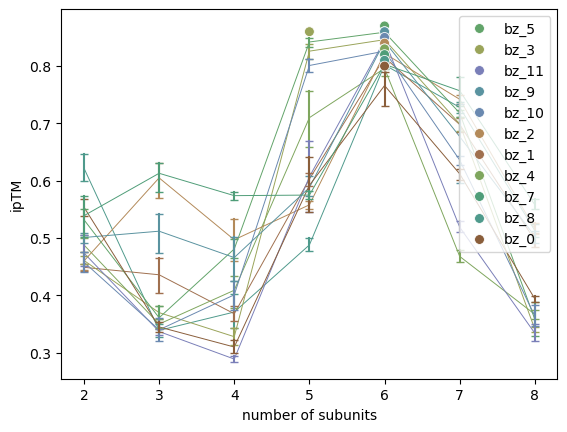

bz_0 ipTM range (6mer with ATP): 0.47 - 0.75
bz_1 ipTM range (6mer with ATP): 0.55 - 0.62
bz_10 ipTM range (6mer with ATP): 0.77 - 0.84
bz_11 ipTM range (6mer with ATP): 0.51 - 0.78
bz_2 ipTM range (6mer with ATP): 0.54 - 0.57
bz_3 ipTM range (6mer with ATP): 0.79 - 0.86
bz_4 ipTM range (6mer with ATP): 0.55 - 0.8
bz_5 ipTM range (6mer with ATP): 0.82 - 0.86
bz_7 ipTM range (6mer with ATP): 0.56 - 0.6
bz_8 ipTM range (6mer with ATP): 0.46 - 0.52
bz_9 ipTM range (6mer with ATP): 0.55 - 0.66


In [20]:
# Structure confidence seems to generally be better with bound Mg + ATP, so opting to focus on these predictions.
get_ligand = lambda name : None if (len(name.split('-')) == 1) else name.split('-')[-1]

figure_df = list()
for output in outputs:
    for model, iptm in output.get_iptms(mean_pool=False).items():
        row = {'name':output.name, 'model':model, 'iptm':iptm, 'genome_id':get_genome_id(output.name)}
        row['best_model'] = output.best_model == model
        row['num_subunits'] = get_num_subunits(output.name)
        row['ligand'] = get_ligand(output.name)
        figure_df.append(row)

figure_df = pd.DataFrame(figure_df)
figure_df = figure_df[figure_df.ligand == 'mg_atp'].copy()

fig, ax = plt.subplots()
y = 'iptm'

sns.lineplot(figure_df, x='num_subunits', y=y, hue='genome_id', lw=0.7, palette=GENOME_ID_COLORS, zorder=-1,legend=False, err_style='bars', err_kws={"capsize": 3})

sns.scatterplot(figure_df.sort_values('iptm', ascending=False).drop_duplicates('genome_id'), x='num_subunits', y=y, hue='genome_id', palette=GENOME_ID_COLORS, s=50, zorder=10)

ax.set_ylabel('ipTM')
ax.set_xlabel('number of subunits')

ax.legend().set_title('')
sns.move_legend(ax, loc='upper right')

plt.show()

for genome_id, df in figure_df.groupby('genome_id'):
    print(f'{genome_id} ipTM range (6mer with ATP):', df[df.num_subunits == 5].iptm.min(), '-', df[df.num_subunits == 5].iptm.max())
    
# The ipTMs for structures folded without ATP (or ADP) and Mg were substantially worse, so I elected to focus on the ATP-bound structures. 
# This could reflect the fact that ATP binding stabilizes the oligomer somehow, or possibly promotes oligomerization in the first place. 

In [ ]:
HOLE_INPUT_DIR = '../data/genes/hole/input'
HOLE_OUTPUT_DIR = '../data/genes/hole/output'    
HOLE_MODEL_PATHS = dict()

# Copy the CIF files to the HOLE_INPUT_DIR as PDB files, as HOLE only accepts PDB files.
for output in outputs:
    # Based on ipTM results above, focus on the Mg-ATP bound hexamers only. 
    if (get_ligand(output.name) != 'mg_atp') or (get_num_subunits(output.name) != 6):
        continue 

    models = sorted(list(output.model_paths))
    for i, model in enumerate(models): # Need to replace the model name with an integer because of issues with input file line length limits.
        output_path = os.path.join(HOLE_INPUT_DIR, f'{output.name}.{i}.pdb')
        cif_to_pdb(output.model_paths[model], output_path)

        # HOLE_MODEL_PATHS[output_path] = output.model_paths[model] # Store the path to the original model


In [ ]:
# Something seems to have gone wrong with the bz_3 HOLE prediction when I did an initial run, as the channel seems to have stopped partway through the pore. 
# I am unsure why, as the pore did not seem especially narrow, although perhaps the issue was that the ENDRAD threshold was met). I decreased the
# SAMPLE parameter from the default (0.25) to 0.1 and increased ENDRAD parameter from 25 to 40. This produced much better results; HOLE captured the complete
# channel, and also was more consistent across runs. I then decided to re-run HOLE on all PDB structures using a larger ENRAD and decreased SAMPLE. 

for path in glob.glob(os.path.join(HOLE_INPUT_DIR, '*pdb')): # Iterate over outer directories. 
        
        model = os.path.basename(path).replace('.pdb', '')
        name = model.split('.')[0]

        # alphafold_path = os.path.join(ALPHAFOLD_OUTPUT_DIR, name)

        input_path = os.path.join(HOLE_INPUT_DIR, f'{model}.inp')
        output_path = os.path.join(HOLE_OUTPUT_DIR, f'{model}.sph')
        
        if os.path.exists(output_path):
            continue 
        print(f'Running HOLE analysis on structure model {model}')

        cpoint, cvect = hole_get_axis(PDBFile.from_file(path).to_df())
        cpoint, cvect = ' '.join([str(n) for n in cpoint]), ' '.join([str(n) for n in cvect])

        hole_write_input(input_path, pdb_path=path, cvect=cvect, cpoint=cpoint, output_path=output_path)

        subprocess.run(f'hole < {input_path} > /dev/null', shell=True, check=True)
        sph_to_pdb(output_path)

Running HOLE analysis on structure model bz_5_cluster_3_6mer-mg_atp.6
Running HOLE analysis on structure model bz_8_cluster_3_6mer-mg_atp.6
Running HOLE analysis on structure model bz_2_cluster_3_6mer-mg_atp.7
Running HOLE analysis on structure model bz_3_cluster_3_6mer-mg_atp.1
Running HOLE analysis on structure model bz_11_cluster_3_6mer-mg_atp.5
Running HOLE analysis on structure model bz_11_cluster_3_6mer-mg_atp.3
Running HOLE analysis on structure model bz_9_cluster_3_6mer-mg_atp.5
Running HOLE analysis on structure model bz_1_cluster_3_6mer-mg_atp.4
Running HOLE analysis on structure model bz_4_cluster_3_6mer-mg_atp.6
Running HOLE analysis on structure model bz_1_cluster_3_6mer-mg_atp.8
Running HOLE analysis on structure model bz_9_cluster_3_6mer-mg_atp.0
Running HOLE analysis on structure model bz_0_cluster_3_6mer-mg_atp.0
Running HOLE analysis on structure model bz_3_cluster_3_6mer-mg_atp.8
Running HOLE analysis on structure model bz_0_cluster_3_6mer-mg_atp.4
Running HOLE analy

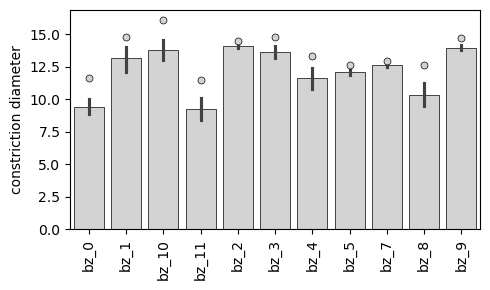

In [50]:
# First, want to look at the approximate pore diameters (which include the Van Der Waals radius). Based on these results, it seems as though the predictions
# for ATP-bound structures are far more consistent, and generally tend to have larger radii. For subsequent analysis, I will focus on the ATP-bound 6mers. 

fig, ax = plt.subplots(figsize=(5, 3))

# Want num_subunits, ligands, and the constriction point. It would also be useful to get PAE at the constriction point (although
# the actual pore-lining residues will be needed for this)
figure_df = list() 

for path in glob.glob(os.path.join(HOLE_OUTPUT_DIR, '*pdb')):
    name, model = os.path.basename(path).replace('.pdb', '').split('.')
    pdb_df = PDBFile.from_file(path).to_df(atoms=['QSS'], residues=['SPH'])

    data = {'name':name, 'model':model, 'genome_id':get_genome_id(name)}
    data['ligand'] = 'ATP' if (('mg_atp') in name) else 'ADP'
    data['num_subunits'] = get_num_subunits(name)
    data['min_radius'] = pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    data['min_diameter'] = 2 * pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    figure_df.append(data)
figure_df = pd.DataFrame(figure_df)


figure_df = figure_df.sort_values(['genome_id', 'min_radius'], ascending=[True, False])
sns.barplot(figure_df, ax=ax, x='genome_id', y='min_diameter', color='lightgray', edgecolor='black', lw=0.5)
sns.stripplot(figure_df.drop_duplicates('genome_id', keep='first'), ax=ax, x='genome_id', y='min_diameter',  color='lightgray', edgecolor='black', linewidth=0.5)
ax.set_xlabel('')
ax.set_ylabel('constriction diameter')
ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=90)

fig.tight_layout()
plt.show()

In [57]:
def get_pore_length(sph_center_coords:np.ndarray) -> float:
    '''Compute the approximate pore length from the HOLE output file.
    
    :param sph_center_coords: The coordinates of the spheres from the HOLE output file. This should be a numpy array with shape (n_atoms, 3).
    :returns: The maximum distance between any two spheres centers, which is taken to be the approximate pore length.  
    
    '''
    dists = pdist(sph_center_coords) # pdist returns the upper triangle of the distance matrix (excluding the diagonal), flattened into a 1D array.
    return max(dists)


def get_pore(path:str, sph_center_coords:np.ndarray=None):
    '''Locates the atoms closest to the pore center for each sphere in the HOLE output. This is accomplished by computing the pairwise distance between
    each sphere and all other atoms in the PDB file, and then returning findiing the atom from each chain which is closest to the sphere center. 
    For each sphere, there will be {num_chains} nearest atoms.
    
    :param path: The path to the PDB file containing the AlphaFold structure used to generate the HOLE output. 
    :param sph_center_coords: The coordinates of the spheres from the HOLE output file. This should be a numpy array with shape (n_atoms, 3).
    :returns: 
    '''
    pore_df = list()

    pdb_df = PDBFile.from_file(path, format='pdb').to_df().drop(columns='b_factor')
    pdb_df = pdb_df.melt(value_name='coord', var_name='atom', id_vars=['residue_num', 'residue', 'chain_id'])
    pdb_df = pdb_df.dropna()
    coords = np.array(pdb_df['coord'].tolist())

    for i, coord in enumerate(sph_center_coords):
        coord = np.expand_dims(coord, axis=0)
        dists = cdist(coord, coords).ravel()

        df = pdb_df.copy().assign(distance=dists, sph_idx=i)
        df = df.sort_values('distance', ascending=True).drop_duplicates('chain_id')
        pore_df.append(df)

    return pd.concat(pore_df)


if os.path.exists('../data/genes/cluster_3_pores.csv'):
    
    pore_df = list()
    for path in tqdm(glob.glob(os.path.join(HOLE_OUTPUT_DIR, '*pdb')), desc='Finding pore-lining residues.'):


        model = os.path.basename(path).replace('.pdb', '')
        name = model.split('.')[0]
        pdb_path = os.path.join(HOLE_INPUT_DIR, model + '.pdb') # Path to the PDB file used to generate the HOLE output. 

        hole_df = PDBFile.from_file(path, format='pdb').to_df(atoms=['QSS'], residues=['SPH'])
        hole_df = hole_df.sort_values('residue_num') # Residue number is the position along the pore. 
        
        # This should be in order of position through the channel (which is the pseudo-"residue number" in the PDB file). 
        sph_center_coords = np.array(hole_df['QSS'].tolist()) # Should be a numpy array with shape (n_atoms, 3). 

        df = get_pore(pdb_path, sph_center_coords=sph_center_coords)
        df['name'], df['model'], df['genome_id'] = name, model, get_genome_id(name)
        df['pore_length'] = get_pore_length(sph_center_coords)
        pore_df += [df]

    pore_df = pd.concat(pore_df)
    pore_df.to_csv('../data/genes/cluster_3_pores.csv', index=False)

pore_df = pd.read_csv('../data/genes/cluster_3_pores.csv')

Finding pore-lining residues.:   0%|          | 0/110 [00:00<?, ?it/s]

Finding pore-lining residues.: 100%|██████████| 110/110 [14:23<00:00,  7.85s/it]


In [64]:
genes_df.loc['orfm.bz_5.1_151'].seq

'VKKMILSNIEILKLILSRYVVIFGGRYSRGKSLSLTALNFFDIMLNGRNNFISNMPVKYPINHKVVPLISTSQFDGFENIINIIYDEIHLDLNARNFNSIVNKYINIFGRDIAKIDGRLRGSVQFFDTLEKVIGLLLEVTILPEYVNKYSNDTKEDNRLRLEHKDFIMKWIIHDNRENEDYELILNLYPFIFMYNTKFKTQPMFLNHKEYVQNIKEKKPKEFKFYEERKKDEILVRLNNWNTGYLEIGKELIR'

plot_pore: Minimum diameter of 16.32228415982775 at SPH 774.


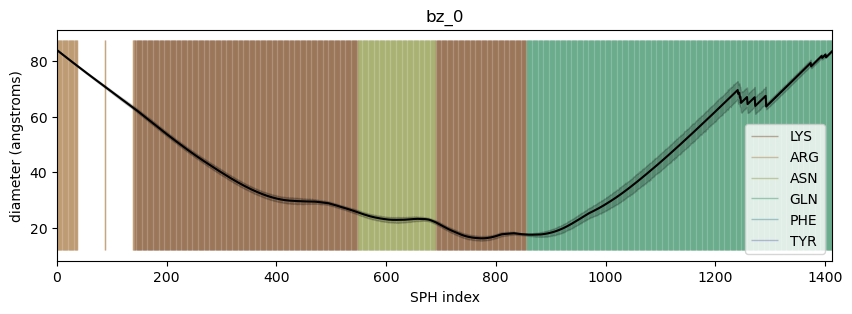

In [60]:
residues = ['LYS', 'ARG', 'ASN',  'GLN', 'PHE', 'TYR']
colors = ['#8A5E3B', '#B38A5A', '#9AA45A', '#4F9D78', '#5A93A0', '#7A7FB8']
palette = dict(zip(residues, colors))

def plot_pore(pore_df:pd.DataFrame, palette=palette, path:str=None, title:str=None):

    figure_df = pore_df.copy()
    figure_df['diameter'] = figure_df.distance * 2 # This will not include the Van Der Waals radius. 
    figure_df['ligand'] = figure_df['name'].apply(lambda name : 'ATP' if (('mg_atp') in name) else 'ADP')

    # Want to obtain the closest residue from each chain for each sphere center, so there should be num_subunits entries per sph_idx.

    fig, ax = plt.subplots(figsize=(10, 3))

    # I checked, and none of the spheres share the same residue across all models, which could be due to small variations in the 
    # models, or because there are different numbers of spheres... or who knows. 

    df = list()
    for idx, df_ in figure_df.groupby('sph_idx'):
        row = {'sph_idx':idx}
        row['consensus_residue'] = df_.residue.value_counts().index[0]
        row['consensus_residue_confidence'] = (df_.residue == row['consensus_residue']).mean()
        df.append(row)
    figure_df = figure_df.merge(pd.DataFrame(df), how='left', on='sph_idx')

    sns.lineplot(figure_df, x='sph_idx', y='diameter', color='black')
    y_min, y_max = ax.get_ylim()

    for residue, color in palette.items():
        idxs = figure_df[figure_df.consensus_residue == residue].sph_idx.unique()
        ax.vlines(idxs, ymin=y_min, ymax=y_max, color=color, zorder=-1, alpha=0.5, label=residue, lw=1)

    diameters = figure_df.groupby('sph_idx').diameter.mean()
    min_diameter_idx = np.argmin(diameters)
    min_diameter = min(diameters) 
    print(f'plot_pore: Minimum diameter of {min_diameter} at SPH {min_diameter_idx}.')
    ax.legend(loc='lower right')

    ax.set_xlim(xmin=0, xmax=figure_df.sph_idx.max())
    ax.set_xlabel('SPH index')
    ax.set_ylabel('diameter (angstroms)')

    if title is not None:
        ax.set_title(title)

    if path is not None:
        fig.savefig(path, dpi=500, format='png')
    plt.show()

for genome_id, df in pore_df.groupby('genome_id'):
    plot_pore(df, path=os.path.join(FIGURE_DIR, f'pore_{genome_id}_atp.png'), title=genome_id)
    break

# I took a look at the PAEs, which were around 10-15 A around the constriction points. However, because model predictions are consistently 
# predicting fairly small pores, I think it is likely that the substrate is ssDNA.

In [ ]:
# Note that the residue nums in the pore_df are one-indexed, as they are loaded directly from the PDB file.
 
pore_df['gene_id'] = pore_df.genome_id.map(GENOME_ID_TO_GENE_ID_MAP)
pore_df['msa_residue_num'] = pore_df.apply(lambda row : msa.map_idx_to_msa(row.residue_num - 1, row.gene_id), axis=1)


In [96]:
pore_df.msa_residue_num.value_counts()
# Want to look at how frequently certain residue appear as lining the pore. 

df = pore_df.drop_duplicates(['gene_id', 'residue_num']) # Treat all chains as effectively the same. 
df['residue_num'] = df.residue_num - 1
df['msa_residue_num'] = df.apply(lambda row : msa.map_idx_to_msa(row.residue_num, row.gene_id), axis=1)
df['num_genomes'] = df.groupby('msa_residue_num').genome_id.transform('nunique')

df[df.num_genomes >= 11] #.residue.value_counts()
pore_residue_nums = df[df.num_genomes >= 3].msa_residue_num.unique()

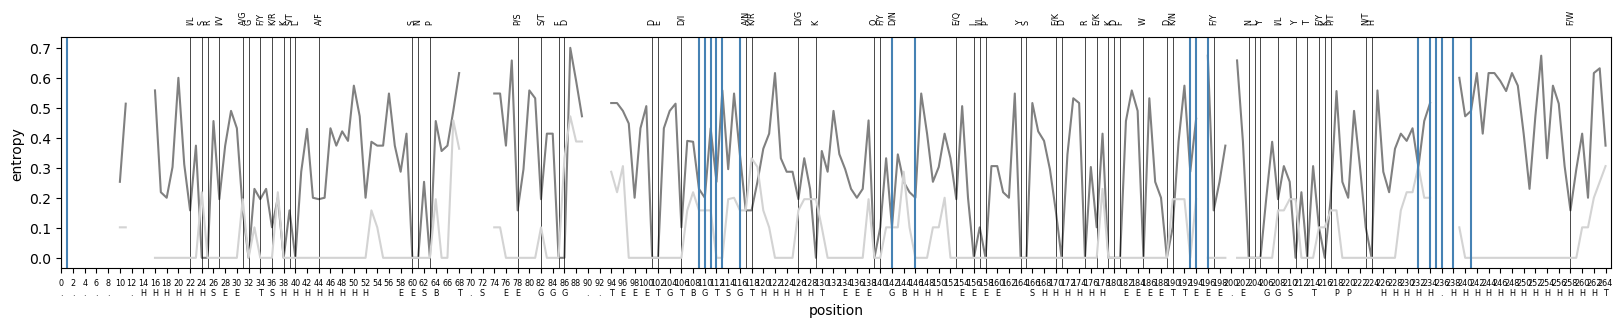

In [97]:
def plot_entropy(msa:MSAFile, max_entropy=0.2, x_min=20, x_max=70, ax:plt.Axes=None, color:str='gray', alphabet:dict=None, annotate:bool=False):

    entropy = msa.get_entropy(alphabet=alphabet, exclude_gaps=True)

    ax.plot(np.arange(len(entropy)), entropy, color=color)

    if annotate:
        conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
        # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
        conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

        for idx, aas in zip(conserved_idxs, conserved_aas):
            if (idx > x_max) or (idx < x_min):
                continue
            ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
            ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 5)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    ax.set_xlabel('position')

x_min, x_max = 0, 265
fig, ax = plt.subplots(figsize=(20, 3))

plot_entropy(msa, ax=ax, x_min=x_min, x_max=x_max, alphabet=None, annotate=True)
plot_entropy(dssp_msa, ax=ax, color='lightgray', x_min=x_min, x_max=x_max)

dssp_consensus = dssp_msa.get_consensus()
x_ticks = np.arange(x_min, x_max, 2)
x_tick_labels = [f'{x}\n{dssp_consensus[x]}' for x in x_ticks]
ax.set_xticks(x_ticks, x_tick_labels, fontsize='xx-small')

for n in pore_residue_nums:
    ax.axvline(n, color='steelblue')

plt.show()

In [83]:
msa.show(start=145)

145	EKILGLMLEVIIIPTFINKYSNDAQEDNLQRLEKKDFTVNWHIIDKKTQE.IFDF.PINLYPFLNMYNTKFKPMPLVINHDEYLHNLQKSS.KKTYEMELEYNQRRLNDNNENWNEGMREI.IINNSDFTLIKELSKQKLTI	287	orfm.bz_2.1_22
145	EKVMGLMLEMIIIPSFVNTYSDDSDKDREIRLEKKDFLVKWKCIDKKADI.IFEI.VINLYPFLNMYNTNFKPYQLVINHESYLEKLKKNK.KNYYNEYVETVDRQINESNVNWYDGLQEI.I................DNY	287	orfm.bz_8.1_215
145	EKRLSDLLQMIIIPTWVKQYSESEKKDIQMRLENKDFRSKWYVIDKKTNN.EYIIPSINLYNFINMYDTNFKTNPLIVTHKEFLQHMKDTKSAQKYENYINDSNERIKYSLEHWLEGEKEL.....................	287	orfm.bz_1.1_155
145	DTALNEIVQIVIIPTFIHTYSNNAKEDNKIRLEKKDFWVLWKIQDKQYDE.AYEL.KLNLYPYIKFYDTNFKPYPLVINHGEYLDKQEKNLTEKKFDNLTDRLREKLSTNCDNWNESYHKLIM..............RSNEP	287	orfm.bz_7.1_194
145	DSSLNEIVQIIIIPTFINQYSQNEKEDIKLRLEHKDFIASWKIIDKKYDD.NYEM.KINLYPFLNMYDTKFKPYPLVINHDEFIEKQEKNLSRLKYDNLIDRINNKLMDNKTNWNNGLTEL.L..............KR.KI	287	orfm.bz_9.1_34
145	EKNMGLILEVIIIPEYVNIYSKITTEDMKKRIENKDFIIKWNIIDKLTNS.EYEL.TLNLYDFIFMYDTNFKPFTLFVNHTEFVEKVKPS....QIDSFRHQEEEELKMRIEHFNDNVFN....................TE	287	orfm.bz_10.1_15


In [ ]:
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'accession', 'description', 'start','stop', 'e_value', 'status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
INTERPROSCAN_ATPASE_ACCESSIONS = ['G3DSA:3.40.50.300', 'SSF52540']

def load_atpase_annotations(path:str, gene_ids:list=None):
    df = pd.read_csv(path, sep='\t', header=None, names=INTERPROSCAN_FIELDS)
    if gene_ids is not None:
        df = df[df.gene_id.isin(gene_ids)].copy()
    df = df[df.accession.isin(INTERPROSCAN_ATPASE_ACCESSIONS)].copy() # P-loop containing nucleoside triphosphate hydrolase
    df = df.sort_values('e_value').drop_duplicates('gene_id')
    df['gene_id'] = df.gene_id.str.lower()
    print(f'load_atpase_annotations: Found {df.gene_id.nunique()} genes with ATPase annotations in {path}.')
    return df.drop(columns=['status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways', 'checksum'])

print('P-loop containing nucleoside triphosphate hydrolase domain indices:')
for row in load_atpase_annotations('../data/genes/interproscan/genes.tsv', gene_ids=genes_df.index.values).itertuples():
    start, stop = msa.map_idx_to_msa(row.start, row.gene_id), msa.map_idx_to_msa(row.stop, row.gene_id)
    print(f'{row.gene_id}\t{start}-{stop}')


P-loop containing nucleoside triphosphate hydrolase domain indices:
load_atpase_annotations: Found 5 genes with ATPase annotations in ../data/genes/interproscan/genes.tsv.
orfm.bz_10.1_15	25-190
orfm.bz_8.1_215	25-158
orfm.bz_9.1_34	24-214
orfm.bz_7.1_194	24-199
orfm.bz_1.1_155	24-200


In [ ]:
WALKER_A_PATTERN = r'[A-Z][A-Z]{4}GK[ST]' # More general version, instead of r'[GAST][A-Z]{4}GK[ST]' 
WALKER_B_PATTERN = r'[AVLIMFYWC]{3,5}D[ED]' # More general version, instead of r'[AVLIMFYWC]{4}D[ED]' 


for row in msa.to_df().itertuples():
    wa_match = re.search(WALKER_A_PATTERN, row.seq)
    wb_match = re.search(WALKER_B_PATTERN, row.seq)

    info = f'{row.Index}'
    if wa_match is not None:
        info += f' Walker-A: {wa_match.group(0)} ({wa_match.start()} - {wa_match.end()})'
    if wb_match is not None:
        info += f' Walker-B: {wb_match.group(0)} ({wb_match.start()} - {wb_match.end()})'
    print(info)

WALKER_A_COORDS = (32, 40)
WALKER_B_COORDS = (96, 103)

for gene_id in genes_df.index:
    genes_df.loc[gene_id, 'walker_a_start'] = msa.map_idx_from_msa(WALKER_A_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_a_stop'] = msa.map_idx_from_msa(WALKER_A_COORDS[1], gene_id)
    genes_df.loc[gene_id, 'walker_b_start'] = msa.map_idx_from_msa(WALKER_B_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_b_stop'] = msa.map_idx_from_msa(WALKER_B_COORDS[1], gene_id)
# Based on the sructure, residues ~100-140 are pointed towards the inside of the toroid. 
# Residues 220-250 also look like they would be in contact with whatever is moving through the toroid. 
# ATPs look like they are binding by the W-A motif, which is good. 

print()
msa.show(start=32, stop=40)

orfm.bz_2.1_22 Walker-B: CIYIMDE (96 - 103)
orfm.bz_8.1_215 Walker-B: IIILDE (97 - 103)
orfm.bz_1.1_155 Walker-A: GEFGRGKT (32 - 40) Walker-B: LFIMDE (97 - 103)
orfm.bz_7.1_194 Walker-A: GEYGRGKS (32 - 40)
orfm.bz_9.1_34 Walker-A: GEYGRGKT (32 - 40)
orfm.bz_10.1_15 Walker-A: GRFGKGKS (32 - 40) Walker-B: LIIWDE (97 - 103)
orfm.bz_5.1_151 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_3.1_43 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_0.1_191 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_4.1_184 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_11.1_23 Walker-A: GRYSRGKS (32 - 40) Walker-B: IVWDE (98 - 103)

32	GEYGRSKS	40	orfm.bz_2.1_22
32	GEFGRCKS	40	orfm.bz_8.1_215
32	GEFGRGKT	40	orfm.bz_1.1_155
32	GEYGRGKS	40	orfm.bz_7.1_194
32	GEYGRGKT	40	orfm.bz_9.1_34
32	GRFGKGKS	40	orfm.bz_10.1_15
32	GRYSRGKS	40	orfm.bz_5.1_151
32	GRYSRGKS	40	orfm.bz_3.1_43
32	GRYSRGKS	40	orfm.bz_0.1_191
32	GRYSRGKS	40	orfm.bz_4.1_184
32	GRYSRGKS	40	orfm.bz_11.1_23


In [ ]:
chimerx_commands = ['color gray']
chimerx_commands += ['sel :lys; color sel blue']
chimerx_commands += ['sel :arg; color sel red']
chimerx_commands += ['sel :tyr; color sel green']
chimerx_commands += ['sel :trp; color sel yellow']
chimerx_commands += ['sel :phe; color sel orange']

print('; '.join(chimerx_commands))

idxs = [139]
chains = 'FC'
atom = 'NZ'
chimerx_commands = list()
for idx in idxs:
    chimerx_commands += [f'select /{chains[0]}:{idx}@{atom} /{chains[1]}:{idx}@{atom}; distance sel']
chimerx_commands += ['color white pseudobonds; color white label']
print('; '.join(chimerx_commands))
# select /B:224@NZ /E:224@NZ
# distance sel 

# color white pseudobonds 
# color white label

# Oddly, the residues which are conserved do not appear to be the ones lining the channel (based on examination of the structures). 
# It seems possible that the structures are off, or possibly adopt different conformations. Might be worth folding with dsDNA and ssDNA and then look at 
# which residues are closest to the nucleic acid through the pore. 

# Some of the pentameric configurations (e.g. bz_3 bound to Mg and ATP) have a pore size that seems too small to be biologically-relevant
# (like 6 angstroms). This would be on the small side, even if the substrate were ssDNA. 

color gray; sel :lys; color sel blue; sel :arg; color sel red; sel :tyr; color sel green; sel :trp; color sel yellow; sel :phe; color sel orange
select /F:139@NZ /C:139@NZ; distance sel; color white pseudobonds; color white label


In [ ]:
# This DataFrame contains the numbers of the pore residues, obtained by manual inspection of the AlphaFold structures. 
chimerx_df = pd.read_csv('../data/genes/cluster_3_chimerx.csv')
chimerx_df['complex_id'] = chimerx_df.apply(lambda row : f'{row.genome_id}_cluster_3_{row.num_subunits}mer', axis=1)
pore_residue_nums = chimerx_df.groupby('complex_id').residue_num.apply(list).to_dict()
# file_name_pattern = r'(bz_\d+)_cluster_3_(5|6)mer-mg_atp_model.cif'



ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
ATOMS = ['NZ', 'CA', 'CB', 'CZ']

pdb_df = list()
for (genome_id, gene_id, num_subunits), df in chimerx_df.groupby(['genome_id', 'gene_id', 'num_subunits']):
    path = os.path.join(ALPHAFOLD_OUTPUT_DIR, f'{genome_id}_cluster_3_{num_subunits}mer-mg_atp', f'{genome_id}_cluster_3_{num_subunits}mer-mg_atp_model.cif')
    pdb_file = PDBFile.from_file(path)
    pdb_df.append(pdb_file.to_df().assign(genome_id=genome_id, gene_id=gene_id, num_subunits=num_subunits))
    
pdb_df = pd.concat(pdb_df)
pdb_df['complex_id'] = pdb_df.apply(lambda row : f'{row.genome_id}_cluster_3_{row.num_subunits}mer', axis=1)

In [ ]:
pore_residue_nums['bz_1_cluster_3_6mer']

[222, 96, 130, 125, 94]

In [ ]:
# Convert AlphaFold structures to PDB for pore analysis using MOLE. 

file_name_pattern = r'(bz_\d+)_cluster_3_(5|6)mer-mg_atp_model.cif'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*', '*')):
    if re.search(file_name_pattern, path) is None:
        continue

    pdb_file = PDBFile.from_file(path)
    output_file_name = os.path.basename(path).replace('.cif', '.pdb')
    output_path = os.path.join(os.path.dirname(path), output_file_name)
    if not os.path.exists(output_path):
        pdb_file.write(output_path)


In [ ]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]

In [ ]:
filters = dict()
filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 100
filters['synthetic'] = foldseek_search_df.target_header.str.contains('Computationally designed|synthetic|de novo|De novo|Engineered')

foldseek_search_df = apply_filters(filters, foldseek_search_df)

# The Foldseek hits from the structures created using the custom MSAs are pretty similar
categories = dict()
categories['genome packaging NTPase'] = foldseek_search_df.target_header.str.contains('genome packaging NTPase')
categories['RecA'] = foldseek_search_df.target_header.str.contains('RecA|RECA|recA')
categories['gp4'] = foldseek_search_df.target_header.str.contains('gp4')
categories['HerA'] = foldseek_search_df.target_header.str.contains('HerA|DUF87') # Hexameric DNA translocase, which operates on dsDNA. 
categories['DnaB'] = foldseek_search_df.target_header.str.contains('DnaB') # Hexameric DNA helicase. 
categories['DnaA'] = foldseek_search_df.target_header.str.contains('DnaA') # Replication initiator, binds to origin and melts duplex DNA. 
categories['zona occludens toxin'] = foldseek_search_df.target_header.str.contains('Zot|Zonula|Zona|Toxin-like protein', case=False)
categories['helicase'] = foldseek_search_df.target_header.str.contains('DNA helicase', case=False)
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False)
categories['AAA family ATPase'] = foldseek_search_df.target_header.str.contains('AAA family ATPase|AAA-domain-containing|ATP-binding|AAA')
categories['ATPase'] = foldseek_search_df.target_header.str.contains('ATPase') & ~categories['AAA family ATPase']
categories['transposase'] = foldseek_search_df.target_header.str.contains('transposase', case=False)
categories['assembly protein'] = foldseek_search_df.target_header.str.contains('assembly', case=False)
categories['filamentous phage'] = foldseek_search_df.target_header.str.contains('Cf1c|Spiroplasmavirus|Plectrovirus', case=False)

categories = list(zip(*list(categories.items())))
foldseek_search_df['category'] = np.select(condlist=categories[-1], choicelist=categories[0], default='none')

foldseek_search_df[foldseek_search_df.query_end < 200].sort_values('alignment_tm_score').drop_duplicates('target_id').iloc[-100:][['query_length', 'target_length', 'query_start', 'query_end', 'target_end', 'target_header']]

apply_filters: 0 entries removed by low_tm_score.
apply_filters: 0 entries removed by low_query_coverage.
apply_filters: 0 entries removed by short_alignment.
apply_filters: 0 entries removed by synthetic.


,query_length,target_length,query_start,query_end,target_end,target_header
43035,244,392,16,197,175,AF-A0A427HJH7-F1-model_v6 Zonular occludens toxin
52677,247,343,14,193,172,AF-A0A2N7BVQ5-F1-model_v6 Zonular occludens toxin
52676,247,343,14,193,172,AF-A5L2V1-F1-model_v6 Zona occludens toxin N-t...
18565,259,151,3,185,151,AF-A0A9N9FTL4-F1-model_v6 20012_t:CDS:1
43043,244,393,16,197,175,AF-A0A0T6UQE5-F1-model_v6 Zonular occludens toxin
...,...,...,...,...,...,...
42505,244,183,7,199,183,AF-X1E310-F1-model_v6 Zona occludens toxin N-t...
43847,248,135,6,144,135,AF-X1CVG9-F1-model_v6 Zona occludens toxin N-t...
37951,253,223,16,168,223,AF-A0A843GSS6-F1-model_v6 AAA family ATPase (F...
52602,247,224,11,167,224,AF-K1SKV5-F1-model_v6 Zona occludens toxin N-t...


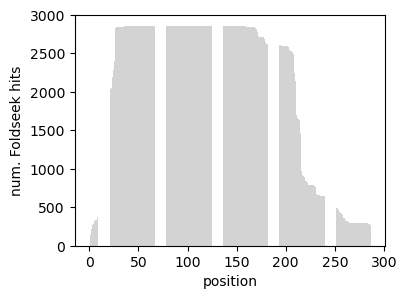

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = foldseek_search_df.copy()
figure_df = foldseek_search_df.drop_duplicates('target_id')
# Get the indices relative to the MSAFile. 
figure_df['msa_start'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_start, row.query_id), axis=1) 
figure_df['msa_stop'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_end, row.query_id), axis=1) 

positions = np.arange(msa.n_cols)
heights = np.zeros(len(positions))
for row in figure_df.itertuples():
    heights[np.arange(row.msa_start, row.msa_stop)] += 1 

ax.bar(positions, heights, color='lightgray', lw=0, edgecolor='black')
ax.set_ylabel('num. Foldseek hits')
ax.set_xlabel('position')
plt.show()

# Most of the hits are to the N-terminal 200 residues, but the helix at the end (last 50 residues or so) is generally not matched. 

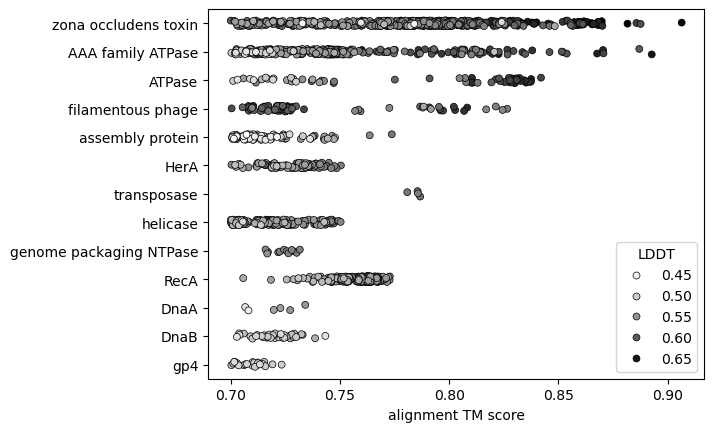

In [ ]:
fig, ax = plt.subplots()

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')
plt.show()

In [ ]:

# DALI_FIELD_MAP = dict()
# DALI_FIELD_MAP['query'] = 'query_id'
# DALI_FIELD_MAP['sbjct'] = 'target_id'
# DALI_FIELD_MAP['seq_identity'] = 'percent_identity'
# DALI_FIELD_MAP['sbjct_sequence'] = 'target_seq'
# DALI_FIELD_MAP['sbject_length'] = 'target_length'
# DALI_FIELD_MAP['sbjct_sequence'] = 'target_seq'
# DALI_FIELD_MAP['compressed_sbjct_dssp'] = 'target_dssp'
# DALI_FIELD_MAP['sstarts'] = 'target_starts'
# DALI_FIELD_MAP['lengths'] = 'alignment_lengths'
# DALI_FIELD_MAP['qstarts'] = 'query_starts'
# DALI_FIELD_MAP['all_pfam'] = 'pfam_data'
# DALI_FIELD_MAP['ali_length'] = 'alignment_length'

# dali_search_df.duplicated(['query_id', 'target_id']).sum()

np.int64(0)

In [ ]:
categories = dict()
categories['RecA'] = foldseek_search_df.theader.str.contains('RecA|recA')
categories['Zot'] = foldseek_search_df.theader.str.contains('Zot|Zona|occludens')
categories['ATPase'] = foldseek_search_df.theader.str.contains('ATP|AAA')
categories['uncharacterized'] = foldseek_search_df.theader.str.contains('uncharacterized', case=False) 
categories['PhoH'] = foldseek_search_df.theader.str.contains('PhoH') 
categories['terminase'] = foldseek_search_df.theader.str.contains('terminase') 
categories['helicase'] = foldseek_search_df.theader.str.contains('helicase', case=False) 
categories['recombinase'] = foldseek_search_df.theader.str.contains('recombinase', case=False) 
categories['transposase'] = foldseek_search_df.theader.str.contains('transposase', case=False) 
categories['RFC'] = foldseek_search_df.theader.str.contains('Replication factor C|Clamp Loader|RFC') 
categories['MutS'] = foldseek_search_df.theader.str.contains('MutS|mismatch repair', case=False) 
categories['thymidine kinase'] = foldseek_search_df.theader.str.contains('thymidine kinase', case=False) 
categories['pilus assembly'] = foldseek_search_df.theader.str.contains('pilus', case=False) # No hits survive the filter. 
# items() output is [(key, value), (key, value), ...]. Then zip() takes the corresponding elements of each tuple, so end up with [(key, key, ...), (value, value, ..)]
categories = list(zip(*list(categories.items())))
foldseek_search_df['category'] = np.select(condlist=categories[-1], choicelist=categories[0], default='none')


In [ ]:
# RecA forms a filament, not a pore, so a RecA-like mechanism is unlikely. 

foldseek_search_df[foldseek_search_df.category == 'helicase'][['theader', 'tcov', 'qcov', 'alntmscore']].sort_values('alntmscore')
foldseek_search_df[['theader', 'tcov', 'qcov', 'alntmscore']].sort_values('alntmscore').iloc[-10:]

,theader,tcov,qcov,alntmscore
153292,AF-X1CVG9-F1-model_v6 Zona occludens toxin N-t...,0.956,0.553,0.9047
195954,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.875,0.9048
117506,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.839,0.9062
135183,A0A6J5KM92,0.362,0.146,0.9067
55250,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.849,0.9069
56466,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.966,0.815,0.9082
77579,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.801,0.9142
151,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.854,0.9181
135155,A0A8S5VDT6,0.376,0.146,0.9209
153182,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.848,0.9217


In [ ]:
genes_df

,nt_seq,description,seq,frame,gene_number,start,stop,strand,partial,has_start_codon,...,seq_untrimmed,nt_seq_untrimmed,num_residues_trimmed,cluster_id,atpase_domain_start,atpase_domain_stop,walker_a_start,walker_a_stop,walker_b_start,walker_b_stop
gene_id,,,,,,,,,,,,,,,,,,,,,
orfm.bz_0.1_191,TTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAAAGGAAA...,NaN,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2,191,1800,2588,-,False,True,...,KSLRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLT...,AAATCTTTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAA...,2,3.0,21.0,206.0,29.0,37.0,88.0,95.0
orfm.bz_1.1_155,ATGACTTCAATATCTGAAATATTTGATATTATTTTTTCAAGGAAAA...,NaN,MTSISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILNNKNN...,1,155,2418,3179,-,False,True,...,KIKIMTSISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILN...,AAAATAAAAATTATGACTTCAATATCTGAAATATTTGATATTATTT...,4,3.0,12.0,197.0,20.0,28.0,79.0,86.0
orfm.bz_2.1_22,ATGAATAAACTTGATTTGCTTCATTCTTTATTTAGTCGCCACATTA...,NaN,MNKLDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNKKLI...,6,22,1172,1982,-,False,True,...,NINMNKLDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNK...,AATATAAATATGAATAAACTTGATTTGCTTCATTCTTTATTTAGTC...,3,3.0,11.0,196.0,19.0,27.0,79.0,86.0
orfm.bz_3.1_43,ATGCAAACAAATAGGAAAATAATGAATAATAAAGAAATAATTGAAT...,NaN,MQTNRKIMNNKEIIELILSRYVVIIGGRYSRGKSLSLTALNFFDMI...,5,43,2530,3331,-,False,True,...,YIPKINKFSMQTNRKIMNNKEIIELILSRYVVIIGGRYSRGKSLSL...,TACATACCAAAAATTAATAAATTTTCAATGCAAACAAATAGGAAAA...,9,3.0,18.0,202.0,26.0,34.0,85.0,92.0
orfm.bz_4.1_184,TTGAAAGAAATTGATATAATACAATTGATATTAAGTAGATATGTGG...,NaN,LKEIDIIQLILSRYVVFVGGRYSRGKSLIITFLTLMDLILNNRNSI...,1,184,4053,4817,-,False,True,...,IGCILKEIDIIQLILSRYVVFVGGRYSRGKSLIITFLTLMDLILNN...,ATAGGGTGTATCTTGAAAGAAATTGATATAATACAATTGATATTAA...,4,3.0,11.0,196.0,19.0,27.0,78.0,85.0
orfm.bz_5.1_151,GTGAAAAAAATGATATTATCCAATATAGAAATATTAAAACTTATAC...,NaN,VKKMILSNIEILKLILSRYVVIFGGRYSRGKSLSLTALNFFDIMLN...,1,151,1325,2095,-,False,True,...,GKVKKMILSNIEILKLILSRYVVIFGGRYSRGKSLSLTALNFFDIM...,GGAAAGGTGAAAAAAATGATATTATCCAATATAGAAATATTAAAAC...,2,3.0,16.0,197.0,24.0,32.0,80.0,87.0
orfm.bz_7.1_194,TTGTTTGTGTGGAATATGAATACAAAAGAAATACTTGATATTATTT...,NaN,LFVWNMNTKEILDIISSRKVILIAGEYGRGKSLSGTALIFMLCVLS...,1,194,1204,1989,-,False,True,...,WLFVWNMNTKEILDIISSRKVILIAGEYGRGKSLSGTALIFMLCVL...,TGGTTGTTTGTGTGGAATATGAATACAAAAGAAATACTTGATATTA...,1,3.0,16.0,201.0,24.0,32.0,84.0,91.0
orfm.bz_8.1_215,ATGAATAATTTAGATAAACTTAATATTATTTTCAGTAGATGGATAA...,NaN,MNNLDKLNIIFSRWIIIFGGEFGRCKSLSITALTFLELLYTKKSKI...,3,215,1806,2576,-,False,True,...,IKIIMNNLDKLNIIFSRWIIIFGGEFGRCKSLSITALTFLELLYTK...,ATCAAGATAATTATGAATAATTTAGATAAACTTAATATTATTTTCA...,4,3.0,11.0,197.0,19.0,27.0,80.0,87.0
orfm.bz_9.1_34,ATGAATAATCAAGAAATATTTGATTTACTGGAATCAAGAAAGGTAA...,NaN,MNNQEIFDLLESRKVIVIAGEYGRGKTLSGIALTWYLTILYQHFNV...,4,34,2676,3426,-,False,True,...,KIMNNQEIFDLLESRKVIVIAGEYGRGKTLSGIALTWYLTILYQHF...,AAAATCATGAATAATCAAGAAATATTTGATTTACTGGAATCAAGAA...,2,3.0,11.0,191.0,19.0,27.0,74.0,81.0


In [ ]:
# Is there a conserved in-frame start codon?
for row in genes_df.itertuples():
    codons = np.array([row.nt_seq[i:i+3] for i in range(0, len(row.nt_seq), 3)])
    start_codon_idxs = np.where(np.isin(codons, ['ATG', 'GTG']))[0]
    print(f'{row.Index} start codon locations:', ' '.join(start_codon_idxs.astype(str)), '-', len(row.seq))

orfm.bz_0.1_191 start codon locations: 10 45 47 53 59 72 84 95 229 249 255 256 - 259
orfm.bz_1.1_155 start codon locations: 0 30 83 86 96 104 137 157 192 213 - 248
orfm.bz_2.1_22 start codon locations: 0 49 83 96 134 191 199 222 242 - 266
orfm.bz_3.1_43 start codon locations: 0 7 44 52 56 94 197 - 257
orfm.bz_4.1_184 start codon locations: 14 35 49 126 165 191 245 246 - 249
orfm.bz_5.1_151 start codon locations: 0 3 43 54 167 192 202 - 253
orfm.bz_7.1_194 start codon locations: 2 5 40 129 171 253 - 259
orfm.bz_8.1_215 start codon locations: 0 49 55 132 135 138 192 - 251
orfm.bz_9.1_34 start codon locations: 0 51 103 119 176 186 228 - 247
orfm.bz_10.1_15 start codon locations: 0 18 31 51 126 131 155 191 230 239 - 244
orfm.bz_11.1_23 start codon locations: 0 3 35 49 61 85 130 188 246 - 249


In [ ]:
# def check_token_chain_ids(token_chain_ids, paes):
#     '''Checks the following conditions:
#         (1) The retrieved token_chain_ids match the index and columns of each PAE DataFrame. 
#         (2) All chains are of equal length. This should be true for all cluster_3 multimer protein chains, as they are all homo-oligomers.'''
#     for _, df in paes.items():
#         assert np.all(token_chain_ids == df.columns.values), f'check_token_chain_ids: Failed condition (1).'
#         assert np.all(token_chain_ids == df.index.values), f'check_token_chain_ids: Failed condition (1).'
#     print('check_token_chain_ids: Condition (1) OK')
#     chain_ids, counts = np.unique(token_chain_ids, return_counts=True)
#     for chain_id, count in zip(chain_ids, counts):
#         assert (df.columns.values == chain_id).sum() == count, f'check_token_chain_ids: The token_chain_ids do not match the DataFrame columns.'
#     print('check_token_chain_ids: Condition (2) OK')


# def get_inter_chain_pae(output:AlphaFoldOutput, residues:list=None, expected_num_chains:int=None):
#     '''Compute the average PAE between corresponding residues on each symmetric cluster_3 chain. 

#     :param residues:
#     :param expected_num_chains:
#     '''
#     token_chain_ids = output.get_token_chain_ids(protein_chains_only=True)
#     paes = output.get_paes(mean_pool=False, protein_chains_only=True)
#     check_token_chain_ids(token_chain_ids, paes)

#     chain_ids, chain_start_idxs = np.unique(token_chain_ids, return_index=True)
#     assert len(chain_ids) == expected_num_chains, f'get_inter_chain_pae: Expected {expected_num_chains} protein chains, but got {len(chain_ids)}.'

#     df = list()

#     for residue in residues:
#         # NOTE: Need to make sure these indices are correct. 
#         idxs = chain_start_idxs + (residue['residue_num'] - 1)
#         for model, df_ in paes.items():
#             values = df_.iloc[idxs, idxs].to_numpy()
#             row = {'model':model, 'name':output.name, 'residue':residue}
#             row.update(residue)
#             row['paes'] = sorted(values[np.triu_indices(len(idxs), k=1)].tolist()) # Need to use triu_indeixes instead of triu, because triu just sets things to zero.
#             row['mean_pae'] = np.mean(row['paes'])
#             row['min_pae'] = min(row['paes'])
#             df.append(row)
        
#     return pd.DataFrame(df)

# Get all residues predicted to be pore-adjacent from any sphere in any model.
# residues = dict()
# for genome_id, df in pore_df.groupby('genome_id'):
#     df = df[['distance', 'residue_num', 'residue']].sort_values('distance').drop_duplicates('residue_num')
#     residues[genome_id] = df.to_dict(orient='records')


In [ ]:
# HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

# window_size = 20
# step_size = 10

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

# get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

# fig, ax = plt.subplots(figsize=(10, 3.5))

# for row in genes_df.itertuples():
#     window_starts = list(range(0, len(row.seq), step_size))[:-1]
#     windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]

#     hydrophobicity = [get_hydrophobicity(seq) for seq in windows]

#     ax.plot(window_starts, hydrophobicity, label=row.Index, color=palette[row.Index])

# ax.set_ylabel('hydrophobicity')
# ax.set_xlabel('position')
# ax.axhline(1, ls='--', color='black', lw=0.7)
# plt.show()

In [ ]:
# def dssp_add_pdb_header(path, output_dir='../data/genes/dssp/cluster_1/'):
#     # '''The ColabFold output PDB files contain ATOM entries for hydrogens, which is not compatible with the DSSP parser.'''
#     with open(path, 'r') as f:
#         lines = f.readlines()

#     # has_hydrogen = lambda line : line.strip().split()[-1] == 'H'
#     # lines = [line for line in lines if not has_hydrogen(line)]
#     lines = ['HEADER\tPROTEIN']
#     output_path = os.path.join(output_dir, os.path.basename(path))
#     with open(output_path, 'w') as f:
#         f.write('\n'.join(lines))
#     return output_path
    

In [ ]:
# # Want to look for conserved arginine and/or lysine residues which could be involved in DNA binding (excluding the conserved R/K in the
# # Walker-A motif, which is for ATP binding).

# is_dna_binding = lambda aas : np.all(np.isin(aas, ['R', 'K']))

# dna_binding_idxs = list()
# for idx, aas in zip(conserved_idxs, conserved_aas):
#     if not is_dna_binding(aas):
#         continue
#     if np.isin(idx, np.arange(WALKER_A_COORDS[0], WALKER_A_COORDS[1] + 1)):
#         print(f'Skipping index {idx} because it is part of the Walker-A motif.')
#         continue 
#     if np.isin(idx, np.arange(WALKER_B_COORDS[0], WALKER_B_COORDS[1] + 1)):
#         print(f'Skipping index {idx} because it is part of the Walker-B motif.')
#         continue 
#     dna_binding_idxs.append(idx)

# print('Number of candidate DNA-binding residues:', len(dna_binding_idxs))



In [ ]:
# ! muscle -align ../data/genes/atpase_domains.faa -output ../data/genes/atpase_domains.afa
# atpase_domains_msa = MSA('../data/genes/atpase_domains.afa')
# print(str(atpase_domains_msa))

# CARETTA_INPUT_DIR = '../data/genes/caretta/structures/atpase_domains/'
# CARETTA_OUTPUT_DIR = '../data/genes/caretta/atpase_domains.out/'
# cmd = f'\ncaretta-cli {CARETTA_INPUT_DIR} --no-pdb --matrix --output {CARETTA_OUTPUT_DIR} --features\n'
# print(cmd)

# paths = {gene_id:f'../data/genes/alphafold/fold_{gene_id}_1mer_mg_atp/fold_{gene_id}_1mer_mg_atp_model_0.cif' for gene_id in seqs.keys()}

# pattern = r'|'.join([fr'{gene_id}_relaxed_rank_001_alphafold2_ptm_model_\d_seed_000.pdb' for gene_id in genes_df.index])
# paths.update({get_gene_id(path):path for path in glob.glob('../data/genes/colabfold/*/*pdb') if (re.search(pattern, path) is not None)})

# # For the structural alignment, want to subset the structure to match the ATPase domain. 
# for gene_id, path in paths.items():
#     if gene_id[:2] == 'or':
#         output_path = os.path.join(CARETTA_INPUT_DIR, f'{gene_id.lower()}_atpase_domain.pdb')
#         start, stop = atpase_df.loc[gene_id].start, atpase_df.loc[gene_id].stop
#         PDBFile.from_file(path).subset(output_path, start=start, stop=stop)

# # caretta -i ./structures/atpase_domains -o ./
# atpase_domain_msa = MSA(f'{CARETTA_OUTPUT_DIR}result.fasta')

In [ ]:
# Commands to run in biotite. Actually, now mkdssp can be run locally! After I installed it according to the instructions on the GitHub. 
# for file_name in os.listdir('../data/genes/dssp/structures/cluster_3/'):
#     gene_id = get_gene_id(file_name)
#     cmd = f'mkdssp /home/philippar/dssp/structures/cluster_3/{file_name} /home/philippar/dssp/{gene_id}.dssp --output-format dssp'
#     # print(cmd)


# print(f'genome ID\thelix start\thelix end\thelix length')
# for path in glob.glob('../data/genes/dssp/*dssp'):
#     if get_genome_id(path) == 'bz_2':
#         # The bz_2 cluster_3 protein has a little extra strand at the end with helix predictions, which I want to ignore. 
#         dssp = str(DSSPFile.from_file(path))[:-12] + ' ' # Add an extra character in case the helix continues to the end of the sequence.
#     else: 
#         dssp = str(DSSPFile.from_file(path)) + ' ' # Add an extra character in case the helix continues to the end of the sequence.
#     dssp = np.array(list(dssp)) # Get the C-terminus as an array. 
    
#     values = np.diff((dssp == 'H').astype(int))
#     stop_idx = np.where(values == -1)[0][-1] # Get the last "helix close" spot. 
#     start_idx = np.where(values == 1)[0][-1] # Get the last "helix open" spot. 
#     print(f'{get_genome_id(path)}\t{start_idx}\t{stop_idx}\t{stop_idx - start_idx}')

In [ ]:
# RESIDUE_CHARGES = {'A':'.', 'C':'.', 'D':'-', 'E':'-', 'F': '.', 'G':'.', 'H':'.', 'I':'.', 'K':'+', 'L':'.', 'M':'.', 'N':'.', 'P':'.', 'Q':'.', 'R':'+', 'S':'.', 'T':'.', 'V':'.', 'W':'.', 'Y':'.'}

# get_charge = lambda seq : ''.join([RESIDUE_CHARGES[aa] for aa in seq])
# get_net_charge = lambda seq : get_charge(seq).count('+') - get_charge(seq).count('-')

# for row in genes_df.itertuples():
#     charges = get_charge(row.seq[-30:])
#     print(f'{row.Index}\t', charges, f'\t({len(charges)}, {100 * charges.count('+') / len(charges):.2f}%, {get_net_charge(row.seq[-30:])})')

In [ ]:
# # First, generate an input file for the AlphaFoldServer to assess if using custom MSAs reduces performance. 
# # It does seem as though the custom MSA is slightly worse, though very marginally, about 0.05 ipTM and pTM. 
# # If I could build a larger MSA, it could be better, but for now I will just use the custom construct. 


# gene_id, n = genes_df.index[0], 6
# msa_unpaired = get_msas_unpaired([gene_id])[gene_id]

# inputs = list()
# print(f'Generating AlphaFold server inputs for {gene_id}.')

# input = AlphaFoldInputFile(f'{get_genome_id(gene_id)}_cluster_3_{n}mer-mg_atp', dialect='alphafoldserver', version=2, num_seeds=1)
# input.add_seq(genes_df.loc[gene_id].seq, n=n, unpaired_msa=msa_unpaired)
# input.add_mg(n=n)
# input.add_atp(n=n)
# inputs.append(input)

# input = AlphaFoldInputFile(f'{get_genome_id(gene_id)}_cluster_3_{n}mer-mg_atp-no_msa', dialect='alphafoldserver', version=2, num_seeds=1)
# input.add_seq(genes_df.loc[gene_id].seq, n=n)
# input.add_mg(n=n)
# input.add_atp(n=n)
# inputs.append(input)

# inputs = [input.get_info() for input in inputs]
# with open('/home/prichter/Downloads/cluster_3.json', 'w') as f:
#     json.dump(inputs, f)